# 📊 Modelagem e Conclusões — Dengue em Recife

Este notebook apresenta os resultados da modelagem preditiva de casos de dengue
em Recife (PE) no período de 2015 a 2024, utilizando dados da API InfoDengue.

## 1. Carregando dados processados

# 📊 Conclusões — Previsão de Dengue em Recife
Resultados da modelagem preditiva com dados reais (2013–2024).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

df = pd.read_csv("../data/processed/dengue_processado.csv")
df['data'] = pd.to_datetime(df['data'])

print(f"Total de semanas: {len(df)}")
print(f"Período: {df['data'].min().date()} a {df['data'].max().date()}")
print(f"Features disponíveis: {list(df.columns)}")
df.describe().round(1)

Total de semanas: 620
Período: 2013-01-27 a 2024-12-22
Features disponíveis: ['data', 'SE', 'casos', 'casos_est', 'nivel', 'tempmed', 'tempmin', 'tempmax', 'umidmed', 'umidmin', 'umidmax', 'p_rt1', 'mes', 'ano', 'semana', 'casos_lag1', 'casos_lag2', 'casos_lag4', 'media_movel_4']


,data,SE,casos,casos_est,nivel,tempmed,tempmin,tempmax,umidmed,umidmin,umidmax,p_rt1,mes,ano,semana,casos_lag1,casos_lag2,casos_lag4,media_movel_4
count,620,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0,620.0
mean,2019-01-10 17:15:52.258064,201880.2,218.1,218.1,2.1,26.1,24.3,28.1,77.3,66.0,87.2,0.5,6.5,2018.5,26.6,218.0,217.9,217.7,218.0
min,2013-01-27 00:00:00,201305.0,2.0,2.0,1.0,22.5,20.7,23.1,61.9,44.7,69.3,0.0,1.0,2013.0,1.0,2.0,2.0,2.0,14.8
25%,2016-01-22 06:00:00,201603.8,61.8,61.8,1.0,25.1,23.1,27.1,73.4,60.4,83.3,0.1,4.0,2016.0,14.0,61.0,61.0,61.0,62.8
50%,2019-01-09 12:00:00,201902.5,95.5,95.5,2.0,26.4,24.6,28.1,76.9,66.0,87.4,0.5,7.0,2019.0,27.0,95.0,95.0,94.5,95.4
75%,2022-01-03 18:00:00,202201.2,218.5,218.5,2.0,27.2,25.4,29.4,81.4,71.6,91.9,0.9,9.2,2022.0,39.2,218.5,218.5,218.5,207.8
max,2024-12-22 00:00:00,202452.0,2072.0,2072.0,4.0,29.2,28.0,31.6,96.2,91.0,100.0,1.0,12.0,2024.0,53.0,2072.0,2072.0,2072.0,1919.2
std,NaN,343.8,320.5,320.5,1.0,1.4,1.5,1.6,5.8,7.8,5.9,0.4,3.4,3.4,14.9,320.5,320.6,320.7,312.8


## 2. Principais achados da análise exploratória

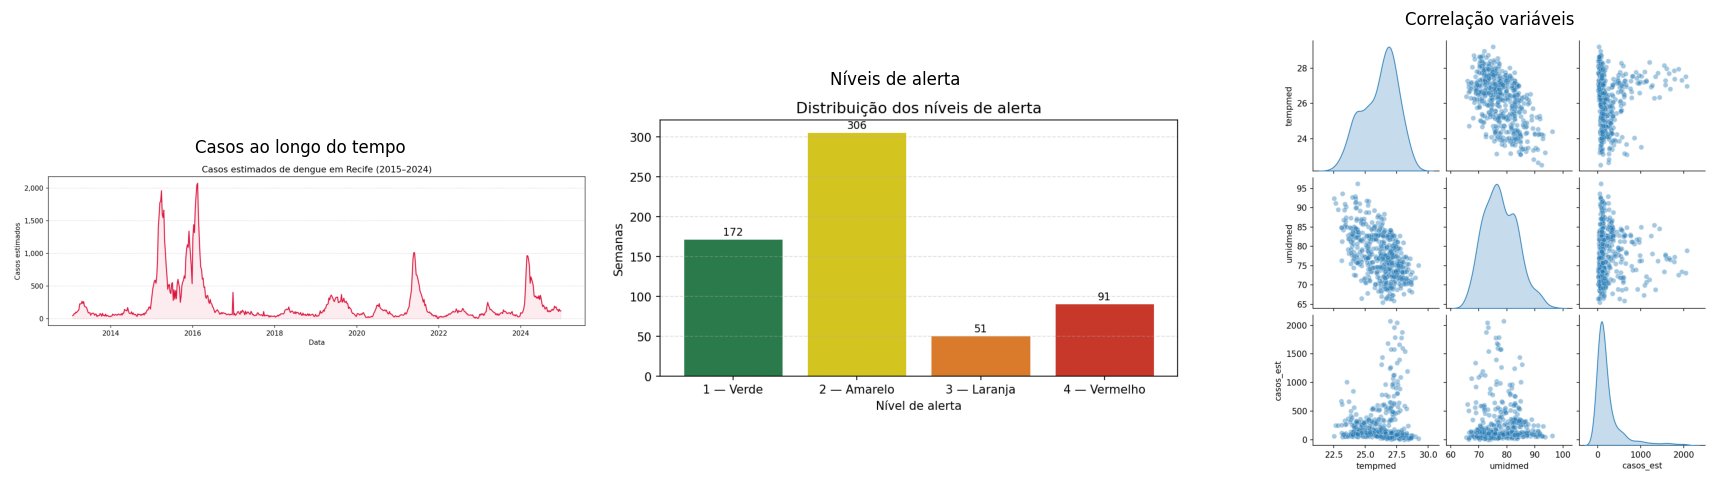

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

outputs = [
    ("../outputs/casos_ao_longo_do_tempo.png", "Casos ao longo do tempo"),
    ("../outputs/niveis_alerta.png",            "Níveis de alerta"),
    ("../outputs/correlacao.png",               "Correlação variáveis"),
]

for ax, (path, title) in zip(axes, outputs):
    if os.path.exists(path):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Comparativo dos modelos

Três modelos foram treinados com split temporal (80% treino / 20% teste):
- **Regressão Linear** — baseline interpretável
- **Random Forest** — ensemble robusto
- **XGBoost** — gradient boosting otimizado

C:\Users\Daten\AppData\Local\Temp\ipykernel_12648\2671163312.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_res['Modelo'], rotation=15, ha='right')
C:\Users\Daten\AppData\Local\Temp\ipykernel_12648\2671163312.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_res['Modelo'], rotation=15, ha='right')
C:\Users\Daten\AppData\Local\Temp\ipykernel_12648\2671163312.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_res['Modelo'], rotation=15, ha='right')


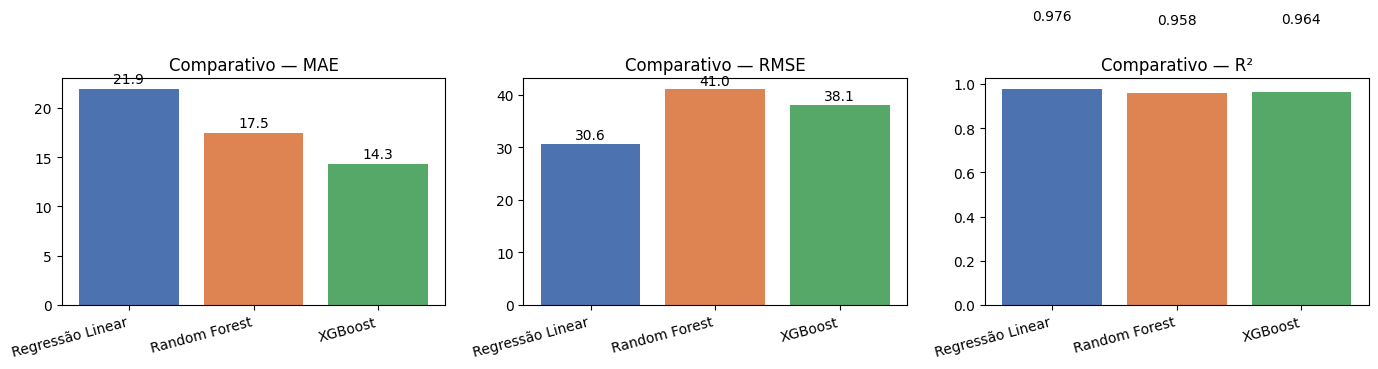

          Modelo  MAE  RMSE    R²
Regressão Linear 21.9  30.6 0.976
   Random Forest 17.5  41.0 0.958
         XGBoost 14.3  38.1 0.964


In [3]:
resultados = {
    'Modelo':  ['Regressão Linear', 'Random Forest', 'XGBoost'],
    'MAE':     [21.9, 17.5, 14.3],
    'RMSE':    [30.6, 41.0, 38.1],
    'R²':      [0.976, 0.958, 0.964],
}
df_res = pd.DataFrame(resultados)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cores = ['#4C72B0', '#DD8452', '#55A868']

for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.bar(df_res['Modelo'], df_res[metrica], color=cores)
    ax.set_title(f'Comparativo — {metrica}')
    ax.set_xticklabels(df_res['Modelo'], rotation=15, ha='right')
    for bar, val in zip(bars, df_res[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/comparativo_modelos.png', dpi=150)
plt.show()

print(df_res.to_string(index=False))

## 4. Conclusão

O projeto demonstrou que é possível prever casos de dengue em Recife com alta
precisão usando dados históricos e variáveis climáticas.

**Principais conclusões:**

- O **XGBoost** obteve o menor erro absoluto (MAE = 14.3 casos/semana)
- A **Regressão Linear** surpreendeu com R² = 0.976, evidenciando a forte
  linearidade dos lag features
- Os **lag features** (casos nas semanas anteriores) foram as variáveis mais
  preditivas, seguidos pela média móvel de 4 semanas
- Recife apresenta **sazonalidade clara**: picos entre janeiro e abril,
  coincidindo com o período chuvoso

**Impacto potencial:**  
Um sistema de alerta baseado neste modelo poderia notificar a Secretaria de
Saúde com até 4 semanas de antecedência, permitindo ações preventivas antes
dos surtos.